# Impact Labelling

This notebook serves as guidelines to label qualitative and quantitative impact information \
Other guidelines can be found here : https://docs.google.com/document/d/1SZk7cou4R6yV44UAxehUqOdqndOFiyHbUCUptlwkk_w/edit?tab=t.0#heading=h.2s6r53ihrgdp

Recommandations
- Work at the sentence level. Each time you identify one or several impacts in a sentence, extract all the information from it. Then continue looping over text sentence
- Information on the date and location can be present in different sentences like in sentences discribing the hazard, but sure not to miss them. 

In [21]:
import pandas as pd
import json
from collections import Counter
import pandas as pd
from src.LLM_functions import *
import copy as cp
import matplotlib.pyplot as plt

from src.data import *

In [3]:
#helper functions
def sort_appeal_type(x):
    pref_order = ["DREF Operation Final Report", "DREF Operation Update", "DREF Operation", "Operations Update"]
    for appealtype in pref_order:
        if appealtype in list(x['appealType']):
            return x[x['appealType'] == appealtype]

def select_report_by_appealCode(appeal_code, report_df):
    report = report_df.where(report_df.appealCode == appeal_code).dropna()
    return report

def print_report(appeal_code, report, text_field="nathaz_text"):
    print(f"{appeal_code}: {report.date}")
    text = report[text_field]
    print("\n".join(text))

def add_report_date(report, impact_dict_or_list):
    if isinstance(impact_dict_or_list, dict):
        impact_dict_or_list["reportDate"] = report.date
    elif isinstance(impact_dict_or_list, list):
        for i in range(len(impact_dict_or_list)):
            impact_dict_or_list[i]["reportDate"] = report.date
    else:
        raise TypeError("impact_dict_or_list must be a dictionary or a list of dictionaries")
    return impact_dict_or_list

def download_report(report, savelocation):
    link = report["reportLink"]
    savename = report["origType"]+".pdf"
    r = requests.get(link)
    with open(savelocation + savename, 'wb') as f:
        f.write(r.content)

def report_dict_to_df(labelled_reports_dict):
    df_list = []
    for k,v in labelled_reports_dict.items():
        df = pd.DataFrame(v)
        df['appealCode'] = k
        df_list.append(df)
    df_all = pd.concat(df_list)
    df_all.reset_index(inplace=True, drop=True)
    return df_all

In [4]:
### Paths
# DATA_IN_JSONS = "..." #### CHANGE
# DATA_LABELLED = "..." #### CHANGE 

In [40]:
#Load data
file_path = DATA_IN_JSONS +'all_ifrc_reports_info_processed_extended_v2.json'

# Open and read the JSON file
with open(file_path, 'r') as json_file:
    filtered_reports = json.load(json_file)
filtered_reports = pd.DataFrame(filtered_reports)

In [28]:
filtered_reports.disasterType.value_counts()

disasterType
Flood                                            893
Cyclone                                          275
Earthquake                                       166
Drought                                          113
Pluvial/Flash Flood                               91
All other disaster and emergencies                81
Volcanic Eruption                                 68
Storm Surge                                       33
Cold Wave                                         33
Fire                                              33
-                                                 24
Landslide                                         17
Cyclone, Storm Surge                               7
Heat Wave                                          6
Hurricane                                          5
Complex Emergency                                  5
Food Insecurity                                    5
Flood, Pluvial/Flash Flood                         4
Cold Wave, All other disaster and

In [33]:
filtered_reports.loc[filtered_reports.disasterType=="Cold Wave"].appealCode.unique()

array(['MDRJO003', 'MDRLB016', 'MDRMN020', 'MDRAF014', 'MDRMN018',
       'MDRLB013', 'MDRMN017', 'MDRPS013', 'MDRPK018', 'MDRMN011',
       'MDRDZ004', 'MDRDZ003', 'MDRMA009', 'MDRMA008', 'MDRMA007'],
      dtype=object)

In [32]:
filtered_reports.loc[filtered_reports.disasterType=="Heat Wave"].appealCode.unique()

array(['MDRBD034', 'MDRKP010'], dtype=object)

In [31]:
filtered_reports.loc[filtered_reports.disasterType=="Earthquake"].appealCode.unique()

array(['MDRSY009', 'MDRMM023', 'MDRMA010', 'MDRTJ036', 'MDRIS001',
       'MDRVU012', 'MDRET037', 'MDRNP015', 'MDRTR004', 'MDRIR007',
       'MDRNP016', 'MDRTJ035', 'MDRIR010', 'MDRIR012', 'MDRID025',
       'MDRHT018', 'MDRDZ005', 'MDRNP013', 'MDRPS014', 'MDRPH047',
       'MDREC019', 'MDRIR013', 'MDRIR004', 'MDRAF010', 'MDRPK021',
       'MDRPE013', 'MDRHR004', 'MDRID020', 'MDRID013', 'MDRHR003',
       'MDRAL008', 'MDRPH036', 'MDRPK016', 'MDRPH034', 'MDRVU007',
       'MDRHT015', 'MDRNP008', 'MDRIQ009', 'MDRPG008', 'MDRSV011',
       'MDREC012', 'MDRID011', 'MDRKG012', 'MDRSB006', 'MDRPH024',
       'MDRPE011', 'MDRTZ020', 'MDRPK012', 'MDRKG011', 'MDRTJ023'],
      dtype=object)

## Prepare data

In [41]:
# select reports to be labelled
# appealCode_list = ["MDRBD022"]  #### UPDATE HERE WITH THE LIST OF APPEAL CODE THAT NEED TO BE LABELLED
# appealCode_list = [
#     "MDRDZ011","MDRPK026","MDRCM039","MDRBJ019","MDRSD034","MDRNG041","MDRRW022",
#     "MDRZM022","MDRUG050","MDRMZ024","MDRAF014","MDRCM036","MDRDZ008","MDRSY006",
#     "MDRBR010","MDRID013","MDR55001","MDRLA009","MDRMG020","MDRNI012","MDRBZ006",
#     "MDRCN006","MDRBD022","MDRYE011","MDRS2001","MDRIQ014","MDRGN015","MDRSV012",
#     "MDRMY003","MDRBD015","MDRKE058","MDRCO023","MDRGW003","MDRHU005","MDRPH021",
#     "MDRRS015","MDRMN017","MDRGT009","MDRTR004","MDRIN028","MDRTN010","MDRCR012",
#     "MDRGE019"
# ]

appealCode_list = ["MDRDZ011","MDRPK026","MDRCM039","MDRBJ019","MDRSD034",
                "MDRNG041","MDRRW022","MDRZM022","MDRUG050","MDRMZ024",
                "MDRAF014","MDRCM036","MDRDZ008","MDRPH036","MDRHT018",
                "MDRID013","MDR55001","MDRJO003","MDRLB013","MDRPK018",
                "MDRTJ035","MDRCN006","MDRBD022","MDRYE011","MDRS2001",
                "MDRIQ014","MDRGN015","MDRSV012","MDRMY003","MDRBD015",
                "MDRKE058","MDRCO023","MDRGW003","MDRHU005","MDRPH021",
                "MDRRS015","MDRMN017","MDRGT009","MDRPG008","MDREC019",
                "MDRTN010","MDRCR012","MDRGE019"]

reports_to_label_all = filtered_reports.loc[filtered_reports["appealCode"].isin(appealCode_list)]#filtered_reports.where(filtered_reports.appealCode.isin(appealCode_list))#.dropna()

#filter by report type
reports_to_label_all = reports_to_label_all.groupby('appealCode', as_index=False).apply(lambda x: sort_appeal_type(x)).reset_index(drop=True)

#convert dates
reports_to_label_all.date = pd.to_datetime(reports_to_label_all.date, dayfirst=True)

#select most recent reports
reports_to_label = reports_to_label_all.groupby('appealCode', as_index=False).apply(lambda x: x.sort_values('date', ascending=False).head(1)).reset_index(drop=True)

#check that everything is there
print(f"Number appealCodes: {len(appealCode_list)}, number reports: {len(reports_to_label)}")

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_30344\4072825396.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reports_to_label_all = reports_to_label_all.groupby('appealCode', as_index=False).apply(lambda x: sort_appeal_type(x)).reset_index(drop=True)


Number appealCodes: 43, number reports: 41


C:\Users\lhasbini\AppData\Local\Temp\ipykernel_30344\4072825396.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reports_to_label = reports_to_label_all.groupby('appealCode', as_index=False).apply(lambda x: x.sort_values('date', ascending=False).head(1)).reset_index(drop=True)


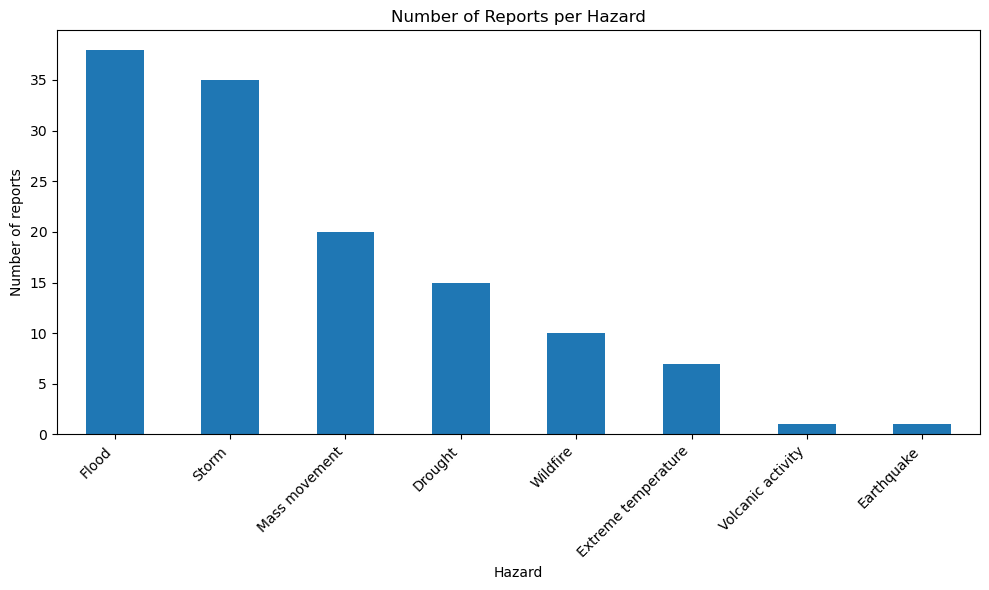

In [42]:
# If hazard is a list → explode it into rows
df_exploded = reports_to_label_all.explode("hazards_found_kw")

# Count hazards
hazard_counts = df_exploded["hazards_found_kw"].value_counts()

# Plot
plt.figure(figsize=(10, 6))
hazard_counts.plot(kind="bar")

plt.ylabel("Number of reports")
plt.xlabel("Hazard")
plt.title("Number of Reports per Hazard")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

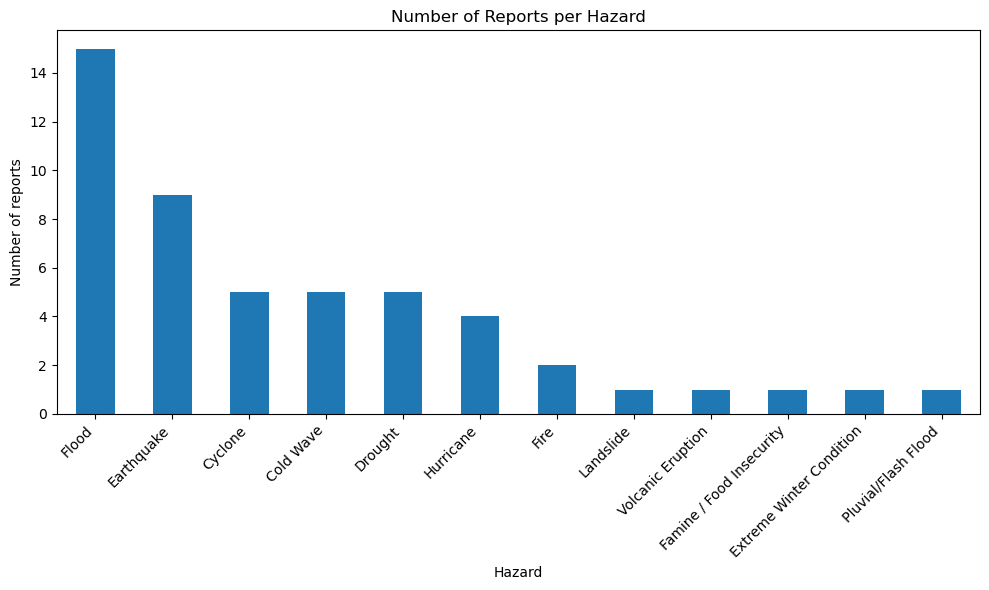

In [46]:
# # If hazard is a list → explode it into rows
# df_exploded = reports_to_label_all.explode("hazards_found_kw")

# Count hazards
hazard_counts = reports_to_label_all["disasterType"].value_counts()

# Plot
plt.figure(figsize=(10, 6))
hazard_counts.plot(kind="bar")

plt.ylabel("Number of reports")
plt.xlabel("Hazard")
plt.title("Number of Reports per Hazard")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [45]:
df_exploded.loc[df_exploded["disasterType"]=="Earthquake"]

,reportName,disasterType,dateTime,date,reportLink,location,appealCode,appealType,origType,pdfDownloaded,...,docName,disasterTypeReclassified,naturalHazard,text_processed,sentences,language,iso_code,hazards_found_kw,nathaz_text,secondaryDisasterType
11,MDREC019fr.pdf,Earthquake,2023-03-28T22:00:00+02:00,2023-03-28,https://go-api.ifrc.org/api/DownloadFile/66414...,Ecuador,MDREC019,DREF Operation Final Report,MDREC019fr,1,...,MDREC019_DREF_Operation_Final_Report_Ecuador_M...,Earthquake,1,public dref operation - final report ecuador |...,[public dref operation - final report ecuador ...,en,ECU,Wildfire,[public public a. situation analysis descripti...,NaN
11,MDREC019fr.pdf,Earthquake,2023-03-28T22:00:00+02:00,2023-03-28,https://go-api.ifrc.org/api/DownloadFile/66414...,Ecuador,MDREC019,DREF Operation Final Report,MDREC019fr,1,...,MDREC019_DREF_Operation_Final_Report_Ecuador_M...,Earthquake,1,public dref operation - final report ecuador |...,[public dref operation - final report ecuador ...,en,ECU,Mass movement,[public public a. situation analysis descripti...,NaN
11,MDREC019fr.pdf,Earthquake,2023-03-28T22:00:00+02:00,2023-03-28,https://go-api.ifrc.org/api/DownloadFile/66414...,Ecuador,MDREC019,DREF Operation Final Report,MDREC019fr,1,...,MDREC019_DREF_Operation_Final_Report_Ecuador_M...,Earthquake,1,public dref operation - final report ecuador |...,[public dref operation - final report ecuador ...,en,ECU,Flood,[public public a. situation analysis descripti...,NaN
11,MDREC019fr.pdf,Earthquake,2023-03-28T22:00:00+02:00,2023-03-28,https://go-api.ifrc.org/api/DownloadFile/66414...,Ecuador,MDREC019,DREF Operation Final Report,MDREC019fr,1,...,MDREC019_DREF_Operation_Final_Report_Ecuador_M...,Earthquake,1,public dref operation - final report ecuador |...,[public dref operation - final report ecuador ...,en,ECU,Storm,[public public a. situation analysis descripti...,NaN
17,Haiti - Earthquake and Cholera (MDRHT018),Earthquake,2023-11-02T20:45:00+01:00,2023-11-02,https://adore.ifrc.org/Download.aspx?FileId=75...,Haiti,MDRHT018,Operations Update,MDRHT018ou6,1,...,MDRHT018_Operations_Update_Haiti_Download.aspx,Earthquake,1,1 operation update haiti | earthquake and chol...,[1 operation update haiti | earthquake and cho...,en,HTI,Wildfire,[a. situation analysis description of the cris...,NaN
17,Haiti - Earthquake and Cholera (MDRHT018),Earthquake,2023-11-02T20:45:00+01:00,2023-11-02,https://adore.ifrc.org/Download.aspx?FileId=75...,Haiti,MDRHT018,Operations Update,MDRHT018ou6,1,...,MDRHT018_Operations_Update_Haiti_Download.aspx,Earthquake,1,1 operation update haiti | earthquake and chol...,[1 operation update haiti | earthquake and cho...,en,HTI,Flood,[a. situation analysis description of the cris...,NaN
17,Haiti - Earthquake and Cholera (MDRHT018),Earthquake,2023-11-02T20:45:00+01:00,2023-11-02,https://adore.ifrc.org/Download.aspx?FileId=75...,Haiti,MDRHT018,Operations Update,MDRHT018ou6,1,...,MDRHT018_Operations_Update_Haiti_Download.aspx,Earthquake,1,1 operation update haiti | earthquake and chol...,[1 operation update haiti | earthquake and cho...,en,HTI,Storm,[a. situation analysis description of the cris...,NaN
18,MDRHT018ou5.pdf,Earthquake,2023-05-30T22:00:00+02:00,2023-05-30,https://go-api.ifrc.org/api/DownloadFile/67807...,Haiti,MDRHT018,Operations Update,MDRHT018ou5,1,...,MDRHT018_Operations_Update_Haiti_MDRHT018ou5,Earthquake,1,1 operation update haiti | earthquake and chol...,[1 operation update haiti | earthquake and cho...,en,HTI,Wildfire,"[after the emergency appeal timeline ends, ifr...",NaN
18,MDRHT018ou5.pdf,Earthquake,2023-05-30T22:00:00+02:00,2023-05-30,https://go-api.ifrc.org/api/DownloadFile/67807...,Haiti,MDRHT018,Operations Update,MDRHT018ou5,1,...,MDRHT018_Operations_Update_Haiti_MDRHT018ou5,Earthquake,1,1 operation update haiti | earthquake and chol...,[1 operation update haiti | earthquake and cho...,en,HTI,Flood,"[after the emergency appeal timeline ends, ifr...",NaN
18,MDRHT018ou5.pdf,Earthquake,2023-05-30T22:00:00

In [43]:
df_exploded.loc[df_exploded["hazards_found_kw"]=="Earthquake"].appealCode.unique()

array(['MDRID013'], dtype=object)

In [14]:
labelled_impact_reports_dict = {} # dict to store labelled reports
#empty dict structure to store results
# labelled_impact_reports_dict["appealCode"]=[
#     {"reportDate": None,
#      "impactSubtype" : None,
#      "impactValue" : None, 
#      "impactUnit" : None, 
#      "impactValuePrecision" : None, 
#      "impactValueMin" : None, 
#      "impactValueMax" : None, 
#      "annotation" : None,
#      "country" : None,
#      "location" : None,
#      "startYear" : None,
#      "startMonth" : None,
#      "startDay" : None,
#      "endYear" : None,
#      "endMonth" : None,
#      "endDay" : None,
#      "hazards" : None,
#     },
# ]

## Labelling 

In [6]:
i=0
print(f"{reports_to_label.iloc[i].appealCode}: {reports_to_label.iloc[i].date}")
reports_to_label.iloc[i].nathaz_text

MDRBD022: 2019-07-19 00:00:00


['DREF operation n MDRBD022 Glide n FL-2019-000079-BGD Date of issue: 18 July 2019 Expected timeframe: 4 months Expected end date: 18 November 2019 Category allocated to the of the disaster or crisis: Orange DREF allocated: CHF 452439 Total number of people affected: 2176519 Number of people to be assisted: 50000 Host National Society presence (n of volunteers, staff, branches): Bangladesh Red Crescent Society (BDRCS) over 575 Red Crescent volunteers and 100 staff mobilized.',
 'Red Cross Red Crescent Movement partners actively involved in the operation: American Red Cross, British Red Cross, Danish Red Cross, German Red Cross, Swedish Red Cross, Swiss Red Cross, Italian Red Cross, Turkish Red Crescent, Qatar Red Crescent and the International Committee of the Red Cross (ICRC).',
 'Other partner organizations actively involved in the operation: Government of Bangladesh, UN RC, UNICEF, WFP, Terre das hommes (TdH), Oxfam, START Network.',
 'A.',
 'Situation analysis Description of the di

In [ ]:
labelled_impact_reports_dict["MDRBD022"]=[
    {"reportDate": "2019-07-19",
     "impactSubtype" : "Affected People",
     "impactValue" : 2176519, 
     "impactUnit" : "people", 
     "impactValuePrecision" : "exact", 
     "impactValueMin" : None, 
     "impactValueMax" : None, 
     "annotation" : ['DREF operation n MDRBD022 Glide n FL-2019-000079-BGD Date of issue 18 July 2019 Expected timeframe 4 months Expected end date 18 November 2019 Category allocated to the of the disaster or crisis Orange DREF allocated CHF 452,439 Total number of people affected 2,176,519 Number of people to be assisted 50,000 Host National Society presence (n of volunteers, staff, branches) Bangladesh Red Crescent Society (BDRCS) over 575 Red Crescent volunteers and 100 staff mobilized.'],
     "country" : ["Bangladesh"],
     "location" : None,
     "startYear" : 2019,
     "startMonth" : 7,
     "startDay" : 18,
     "endYear" : 2019,
     "endMonth" : 11,
     "endDay" : 18,
     "hazards" : ["Flood"]
    },
    {"reportDate": "2019-07-19",
     "impactSubtype" : "Affected People",
     "impactValue" : 1000000, 
     "impactUnit" : "people", 
     "impactValuePrecision" : "approx", 
     "impactValueMin" : None, 
     "impactValueMax" : None, 
     "annotation" : ['While the monsoon season normally brings annual floods to the country and wider region, this year, widespread flooding in upstream countries, Nepal and India, where millions of people have been severely impacted, have meant that the scale of the flooding this year has been significantly exacerbated.'],
     "country" : ["Nepal", "India"],
     "location" : None,
     "startYear" : 2019,
     "startMonth" : None,
     "startDay" : None,
     "endYear" : None,
     "endMonth" : None,
     "endDay" : None,
     "hazards" : ["Flood"]
    },
    {"reportDate": "2019-07-19",
     "impactSubtype" : "Affected People",
     "impactValue" : None, 
     "impactUnit" : "people", 
     "impactValuePrecision" : "approx", 
     "impactValueMin" : 2100000, 
     "impactValueMax" : None, 
     "annotation" : ['According to National disaster response coordination centre (NDRCC) report dated 16 July more than 2.1 million people have been affected in 21 districts, around 100,000 houses destroyed and about 14,733 hectares of crop land damaged.', 
                     'Six days of heavy rain and onrush of upstream waters have flooded low-lying areas of Kurigram, Gaibandha, Lalmonirhat, Chattogram, Bandarban, Rangamati, Sylhet, Sunamganj, Bogura, Nilphamari, Khagrachari, Coxs Bazar, Feni, Netrokona, Sirajganj, Jamalpur, Tangail, Moulavibazar, Habiganj, Sherpur, and Brahmanbaria districts.'],
     "country" : ["Bangladesh"],
     "location" : ["Kurigram district", "Gaibandha district", "Lalmonirhat district", "Chattogram district", "Bandarban district", "Rangamati district", "Sylhet district", "Sunamganj district", "Bogura district", "Nilphamari district", "Khagrachari district", "Coxs Bazar district", "Feni district", "Netrokona district", "Sirajganj district", "Jamalpur district", "Tangail district", "Moulavibazar district", "Habiganj district", "Sherpur district", "Brahmanbaria district"],
     "startYear" : 2019,
     "startMonth" : 7,
     "startDay" : 16,
     "endYear" : None,
     "endMonth" : None,
     "endDay" : None,
     "hazards" : ["Flood"]
    },
    {"reportDate": "2019-07-19",
     "impactSubtype" : "Residential Buildings",
     "impactValue" : 10000, 
     "impactUnit" : "houses destroyed", 
     "impactValuePrecision" : "approx", 
     "impactValueMin" : None, 
     "impactValueMax" : None, 
     "annotation" : ['According to National disaster response coordination centre (NDRCC) report dated 16 July more than 2.1 million people have been affected in 21 districts, around 100,000 houses destroyed and about 14,733 hectares of crop land damaged.', 
                     'Six days of heavy rain and onrush of upstream waters have flooded low-lying areas of Kurigram, Gaibandha, Lalmonirhat, Chattogram, Bandarban, Rangamati, Sylhet, Sunamganj, Bogura, Nilphamari, Khagrachari, Coxs Bazar, Feni, Netrokona, Sirajganj, Jamalpur, Tangail, Moulavibazar, Habiganj, Sherpur, and Brahmanbaria districts.'],
     "country" : ["Bangladesh"],
     "location" : ["Kurigram district", "Gaibandha district", "Lalmonirhat district", "Chattogram district", "Bandarban district", "Rangamati district", "Sylhet district", "Sunamganj district", "Bogura district", "Nilphamari district", "Khagrachari district", "Coxs Bazar district", "Feni district", "Netrokona district", "Sirajganj district", "Jamalpur district", "Tangail district", "Moulavibazar district", "Habiganj district", "Sherpur district", "Brahmanbaria district"],
     "startYear" : 2019,
     "startMonth" : 7,
     "startDay" : 16,
     "endYear" : None,
     "endMonth" : None,
     "endDay" : None,
     "hazards" : ["Flood"]
    },
    {"reportDate": "2019-07-19",
     "impactSubtype" : "Crop Production and Forestry",
     "impactValue" : 14733, 
     "impactUnit" : "hectares of crops", 
     "impactValuePrecision" : "approx", 
     "impactValueMin" : None, 
     "impactValueMax" : None, 
     "annotation" : ['According to National disaster response coordination centre (NDRCC) report dated 16 July more than 2.1 million people have been affected in 21 districts, around 100,000 houses destroyed and about 14,733 hectares of crop land damaged.', 
                     'Six days of heavy rain and onrush of upstream waters have flooded low-lying areas of Kurigram, Gaibandha, Lalmonirhat, Chattogram, Bandarban, Rangamati, Sylhet, Sunamganj, Bogura, Nilphamari, Khagrachari, Coxs Bazar, Feni, Netrokona, Sirajganj, Jamalpur, Tangail, Moulavibazar, Habiganj, Sherpur, and Brahmanbaria districts.'],
     "country" : ["Bangladesh"],
     "location" : ["Kurigram district", "Gaibandha district", "Lalmonirhat district", "Chattogram district", "Bandarban district", "Rangamati district", "Sylhet district", "Sunamganj district", "Bogura district", "Nilphamari district", "Khagrachari district", "Coxs Bazar district", "Feni district", "Netrokona district", "Sirajganj district", "Jamalpur district", "Tangail district", "Moulavibazar district", "Habiganj district", "Sherpur district", "Brahmanbaria district"],
     "startYear" : 2019,
     "startMonth" : 7,
     "startDay" : 16,
     "endYear" : None,
     "endMonth" : None,
     "endDay" : None,
     "hazards" : ["Flood"]
    },
    {"reportDate": "2019-07-19",
     "impactSubtype" : "Road Infrastructure",
     "impactValue" : None, 
     "impactUnit" : None, 
     "impactValuePrecision" : None, 
     "impactValueMin" : None, 
     "impactValueMax" : None, 
     "annotation" : ['It is also reported that embankments have been damaged and inundated in new areas.', 
                     'Six days of heavy rain and onrush of upstream waters have flooded low-lying areas of Kurigram, Gaibandha, Lalmonirhat, Chattogram, Bandarban, Rangamati, Sylhet, Sunamganj, Bogura, Nilphamari, Khagrachari, Coxs Bazar, Feni, Netrokona, Sirajganj, Jamalpur, Tangail, Moulavibazar, Habiganj, Sherpur, and Brahmanbaria districts.'],
     "country" : ["Bangladesh"],
     "location" : ["Kurigram district", "Gaibandha district", "Lalmonirhat district", "Chattogram district", "Bandarban district", "Rangamati district", "Sylhet district", "Sunamganj district", "Bogura district", "Nilphamari district", "Khagrachari district", "Coxs Bazar district", "Feni district", "Netrokona district", "Sirajganj district", "Jamalpur district", "Tangail district", "Moulavibazar district", "Habiganj district", "Sherpur district", "Brahmanbaria district"],
     "startYear" : 2019,
     "startMonth" : 7,
     "startDay" : 16,
     "endYear" : None,
     "endMonth" : None,
     "endDay" : None,
     "hazards" : ["Flood"]
    },
    {"reportDate": "2019-07-19",
     "impactSubtype" : "Affected People",
     "impactValue" : 2176519, 
     "impactUnit" : "people", 
     "impactValuePrecision" : "exact", 
     "impactValueMin" : None, 
     "impactValueMax" : None, 
     "annotation" : ['of affected population 2,176,519 No.', 
                     'Six days of heavy rain and onrush of upstream waters have flooded low-lying areas of Kurigram, Gaibandha, Lalmonirhat, Chattogram, Bandarban, Rangamati, Sylhet, Sunamganj, Bogura, Nilphamari, Khagrachari, Coxs Bazar, Feni, Netrokona, Sirajganj, Jamalpur, Tangail, Moulavibazar, Habiganj, Sherpur, and Brahmanbaria districts.'],
     "country" : ["Bangladesh"],
     "location" : ["Kurigram district", "Gaibandha district", "Lalmonirhat district", "Chattogram district", "Bandarban district", "Rangamati district", "Sylhet district", "Sunamganj district", "Bogura district", "Nilphamari district", "Khagrachari district", "Coxs Bazar district", "Feni district", "Netrokona district", "Sirajganj district", "Jamalpur district", "Tangail district", "Moulavibazar district", "Habiganj district", "Sherpur district", "Brahmanbaria district"],
     "startYear" : 2019,
     "startMonth" : 7,
     "startDay" : 16,
     "endYear" : None,
     "endMonth" : None,
     "endDay" : None,
     "hazards" : ["Flood"]
    },
    {"reportDate": "2019-07-19",
     "impactSubtype" : "Residential Buildings",
     "impactValue" : 3988, 
     "impactUnit" : "houses damaged", 
     "impactValuePrecision" : "exact", 
     "impactValueMin" : None, 
     "impactValueMax" : None, 
     "annotation" : ['of fully damaged house 3,988 No.', 
                     'Six days of heavy rain and onrush of upstream waters have flooded low-lying areas of Kurigram, Gaibandha, Lalmonirhat, Chattogram, Bandarban, Rangamati, Sylhet, Sunamganj, Bogura, Nilphamari, Khagrachari, Coxs Bazar, Feni, Netrokona, Sirajganj, Jamalpur, Tangail, Moulavibazar, Habiganj, Sherpur, and Brahmanbaria districts.'],
     "country" : ["Bangladesh"],
     "location" : ["Kurigram district", "Gaibandha district", "Lalmonirhat district", "Chattogram district", "Bandarban district", "Rangamati district", "Sylhet district", "Sunamganj district", "Bogura district", "Nilphamari district", "Khagrachari district", "Coxs Bazar district", "Feni district", "Netrokona district", "Sirajganj district", "Jamalpur district", "Tangail district", "Moulavibazar district", "Habiganj district", "Sherpur district", "Brahmanbaria district"],
     "startYear" : 2019,
     "startMonth" : 7,
     "startDay" : 16,
     "endYear" : None,
     "endMonth" : None,
     "endDay" : None,
     "hazards" : ["Flood"]
    },
    {"reportDate": "2019-07-19",
     "impactSubtype" : "Residential Buildings",
     "impactValue" : 98571, 
     "impactUnit" : "houses partially damaged", 
     "impactValuePrecision" : "exact", 
     "impactValueMin" : None, 
     "impactValueMax" : None, 
     "annotation" : ['of partially damaged house 98,571 No.', 
                     'Six days of heavy rain and onrush of upstream waters have flooded low-lying areas of Kurigram, Gaibandha, Lalmonirhat, Chattogram, Bandarban, Rangamati, Sylhet, Sunamganj, Bogura, Nilphamari, Khagrachari, Coxs Bazar, Feni, Netrokona, Sirajganj, Jamalpur, Tangail, Moulavibazar, Habiganj, Sherpur, and Brahmanbaria districts.'],
     "country" : ["Bangladesh"],
     "location" : ["Kurigram district", "Gaibandha district", "Lalmonirhat district", "Chattogram district", "Bandarban district", "Rangamati district", "Sylhet district", "Sunamganj district", "Bogura district", "Nilphamari district", "Khagrachari district", "Coxs Bazar district", "Feni district", "Netrokona district", "Sirajganj district", "Jamalpur district", "Tangail district", "Moulavibazar district", "Habiganj district", "Sherpur district", "Brahmanbaria district"],
     "startYear" : 2019,
     "startMonth" : 7,
     "startDay" : 16,
     "endYear" : None,
     "endMonth" : None,
     "endDay" : None,
     "hazards" : ["Flood"]
    },
    {"reportDate": "2019-07-19",
     "impactSubtype" : "Displaced People",
     "impactValue" : 31818, 
     "impactUnit" : "people", 
     "impactValuePrecision" : "exact", 
     "impactValueMin" : None, 
     "impactValueMax" : None, 
     "annotation" : ['of people who have moved to safe shelter 31,818 Amount of crop land damaged (Hectare) 14,733 No.', 
                     'Six days of heavy rain and onrush of upstream waters have flooded low-lying areas of Kurigram, Gaibandha, Lalmonirhat, Chattogram, Bandarban, Rangamati, Sylhet, Sunamganj, Bogura, Nilphamari, Khagrachari, Coxs Bazar, Feni, Netrokona, Sirajganj, Jamalpur, Tangail, Moulavibazar, Habiganj, Sherpur, and Brahmanbaria districts.'],
     "country" : ["Bangladesh"],
     "location" : ["Kurigram district", "Gaibandha district", "Lalmonirhat district", "Chattogram district", "Bandarban district", "Rangamati district", "Sylhet district", "Sunamganj district", "Bogura district", "Nilphamari district", "Khagrachari district", "Coxs Bazar district", "Feni district", "Netrokona district", "Sirajganj district", "Jamalpur district", "Tangail district", "Moulavibazar district", "Habiganj district", "Sherpur district", "Brahmanbaria district"],
     "startYear" : 2019,
     "startMonth" : 7,
     "startDay" : 16,
     "endYear" : None,
     "endMonth" : None,
     "endDay" : None,
     "hazards" : ["Flood"]
    },
    {"reportDate": "2019-07-19",
     "impactSubtype" : "Crop Production and Forestry",
     "impactValue" : 14733, 
     "impactUnit" : "hectares of crops", 
     "impactValuePrecision" : "exact", 
     "impactValueMin" : None, 
     "impactValueMax" : None, 
     "annotation" : ['of people who have moved to safe shelter 31,818 Amount of crop land damaged (Hectare) 14,733 No.', 
                     'Six days of heavy rain and onrush of upstream waters have flooded low-lying areas of Kurigram, Gaibandha, Lalmonirhat, Chattogram, Bandarban, Rangamati, Sylhet, Sunamganj, Bogura, Nilphamari, Khagrachari, Coxs Bazar, Feni, Netrokona, Sirajganj, Jamalpur, Tangail, Moulavibazar, Habiganj, Sherpur, and Brahmanbaria districts.'],
     "country" : ["Bangladesh"],
     "location" : ["Kurigram district", "Gaibandha district", "Lalmonirhat district", "Chattogram district", "Bandarban district", "Rangamati district", "Sylhet district", "Sunamganj district", "Bogura district", "Nilphamari district", "Khagrachari district", "Coxs Bazar district", "Feni district", "Netrokona district", "Sirajganj district", "Jamalpur district", "Tangail district", "Moulavibazar district", "Habiganj district", "Sherpur district", "Brahmanbaria district"],
     "startYear" : 2019,
     "startMonth" : 7,
     "startDay" : 16,
     "endYear" : None,
     "endMonth" : None,
     "endDay" : None,
     "hazards" : ["Flood"]
    },
    {"reportDate": "2019-07-19",
     "impactSubtype" : "Road Infrastructure",
     "impactValue" : None, 
     "impactUnit" : None, 
     "impactValuePrecision" : None, 
     "impactValueMin" : None, 
     "impactValueMax" : None, 
     "annotation" : ['of union affected 776 Emergency Plan of Action (EPoA) Bangladesh Floods P a g e 2 People watch as water from the swollen Teesta river gush into their neighbourhood in Gaddimari area of Lalmonirhats Hatibandha after a part of the protection embankment collapsed on 13 July afternoon.'],
     "country" : ["Bangladesh"],
     "location" : ["Gaddimari area",  "Lalmonirhats Hatibandha"],
     "startYear" : 2019,
     "startMonth" : 7,
     "startDay" : 13,
     "endYear" : None,
     "endMonth" : None,
     "endDay" : None,
     "hazards" : ["Flood"]
    }
]

In [31]:
df_impact_alldf_impact_list = []
for k,v in labelled_impact_reports_dict_new_haz.items():
    df_impact = pd.DataFrame(v)
    df_impact['appealCode'] = k
    df_impact_list.append(df_impact)
df_impact_all = pd.concat(df_impact_list)
df_impact_all.reset_index(inplace=True, drop=True)

#Save impact csv 
fn = "labelled_reports.csv" ##### CHANGE THE NAME OF THE REPORT TO SAVE
df_impact_all.to_csv(DATA_LABELLED+fn, index=False)